In [52]:
import os
import numpy as np
import pandas as pd

file_path = './test_results_v4_io.xlsx'

df_raw = pd.read_excel(file_path, sheet_name='Sheet1', engine='openpyxl')
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains("Unnamed:")]

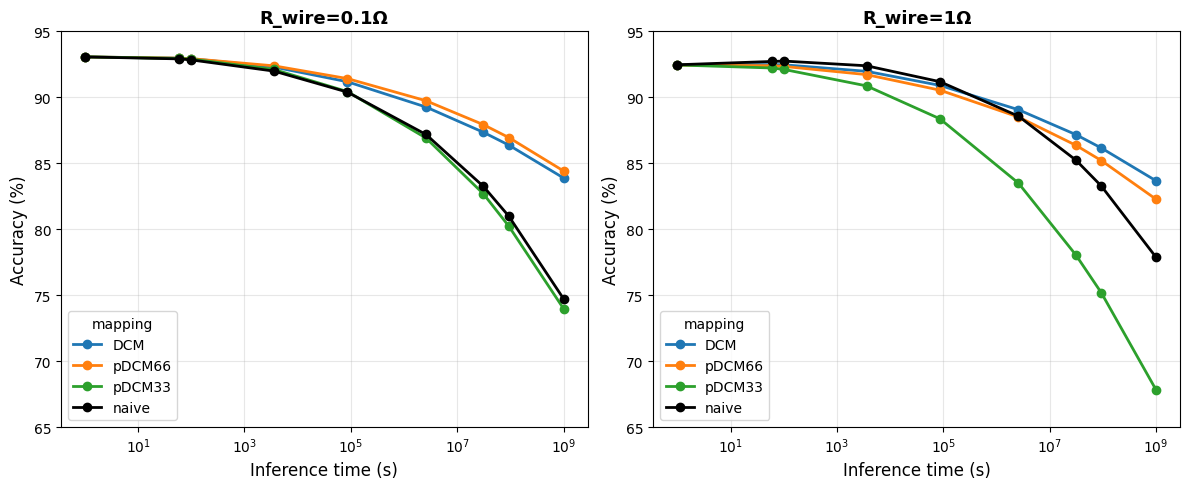

In [53]:
import matplotlib.pyplot as plt

# 1. Filter irdrop == True
df_irdrop = df_raw[df_raw['ir_drop'] == True]
df_irdrop2 = df_irdrop.copy()
df_irdrop = df_irdrop[df_irdrop['R_wire'] < 2]

# Plot 1: xaxis=inf_time, yaxis=accuracy, legend=mapping (by R_wire columns)
r_wire_values = sorted(df_irdrop['R_wire'].unique())
mapping_values = ['DCM', 'pDCM66', 'pDCM33', 'naive']  # Custom order
num_cols = len(r_wire_values)

fig, axes = plt.subplots(1, num_cols, figsize=(6 * num_cols, 5), squeeze=False)

for col_idx, r_wire in enumerate(r_wire_values):
    ax = axes[0, col_idx]
    df_subset = df_irdrop[df_irdrop['R_wire'] == r_wire]
    
    for mapping_val in mapping_values:
        df_map = df_subset[df_subset['mapping'] == mapping_val]
        if df_map.empty:
            continue
        color = 'black' if mapping_val == 'naive' else None
        ax.plot(df_map['inf_time'], df_map['accuracy'],
                marker='o', label=f'{mapping_val}', linewidth=2, markersize=6, color=color)

    ax.set_xlabel('Inference time (s)', fontsize=12)
    ax.set_xscale('log')
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'R_wire={r_wire:g}Ω', fontsize=13, fontweight='bold')
    ax.legend(title='mapping')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(65, 95)
    
plt.tight_layout()
plt.show()

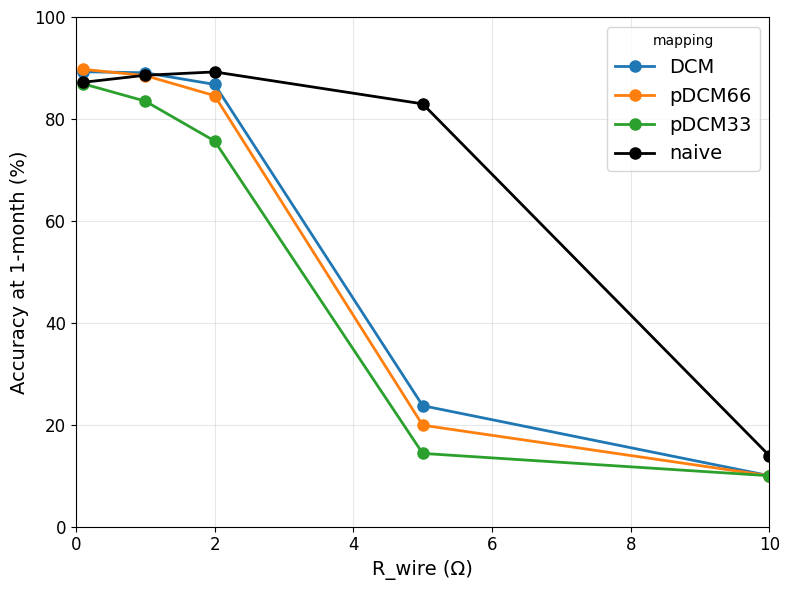

In [62]:
# Plot 2: Filter inf_time == 2592000, xaxis=R_wire, yaxis=accuracy
df_filtered = df_irdrop2[df_irdrop2['inf_time'] == 2592000]

mapping_values = ['DCM', 'pDCM66', 'pDCM33', 'naive']  # Custom order

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for mapping_val in mapping_values:
    df_subset = df_filtered[df_filtered['mapping'] == mapping_val]
    if df_subset.empty:
        continue
    # Sort by R_wire
    df_subset = df_subset.sort_values('R_wire')
    color = 'black' if mapping_val == 'naive' else None
    ax.plot(df_subset['R_wire'], df_subset['accuracy'], 
            marker='o', label=f'{mapping_val}', linewidth=2, markersize=8, color=color)

ax.set_xlabel('R_wire (Ω)', fontsize=14)
ax.set_ylabel('Accuracy at 1-month (%)', fontsize=14)
# ax.set_title('Plot 2: R_wire vs accuracy (inf_time=2592000)', fontsize=13, fontweight='bold')
ax.legend(title='mapping', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)
ax.set_xlim(0, 10)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()
